In [1]:
import os
os.environ['ATTN_BACKEND'] = 'flash-attn'   # Can be 'flash-attn' or 'xformers', default is 'flash-attn'
os.environ['SPCONV_ALGO'] = 'auto'        # Can be 'native' or 'auto', default is 'auto'.
                                            # 'auto' is faster but will do benchmarking at the beginning.
                                            # Recommended to set to 'native' if run only once.
os.environ['OMP_NUM_THREADS'] = '4'        # Set the number of threads for OpenMP. Default is 4.
os.environ['TOKENIZERS_PARALLELISM'] = 'false' 
os.environ['USE_FLUX_DEV'] = 'true' 
os.environ['ENABLE_FLUX_CPU_OFFLOAD'] = 'true'  

# import GEMINI_API_KEY from .env file if it exists
from dotenv import load_dotenv
load_dotenv()
if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = os.getenv('GEMINI_API_KEY', '')

from matplotlib import pyplot as plt
import rembg
import torch
from IPython.display import Video

# Import modular components
from modules.model_manager import get_model_manager
from modules.content_moderation import get_content_moderator  
from modules.generation_pipeline import get_generation_pipeline

# CONFIGURATION SETUP 
print("🔧 Configuring TRELLIS pipeline...")
device_config = {
    "flux": "cuda:0",     # FLUX with CPU offloading for max efficiency  
    "trellis": "cuda:0"   # TRELLIS on dedicated GPU (if available)
}

# Auto-detect best configuration based on available hardware
num_gpus = torch.cuda.device_count()
image_model = "gemini" # 'flux' or 'gemini'
model_manager = get_model_manager(device_config, enable_trellis_cpu_offload=True, image_model=image_model)

content_moderator = get_content_moderator()
generation_pipeline = get_generation_pipeline()

# Load all models
flux_pipe, trellis_pipeline, reward_model = model_manager.load_all_models()

# Configure generation pipeline with models
generation_pipeline.set_models(
    flux_pipeline=flux_pipe,
    trellis_pipeline=trellis_pipeline,
    reward_model=reward_model,
    content_moderator=content_moderator
)

# Get generation config
config = model_manager.get_generation_config()
guidance_scale = config["guidance_scale"]
num_inference_steps = config["num_inference_steps"]

print("\n✅ All modules initialized and models loaded")
print(f"📊 Configuration: guidance_scale={guidance_scale}, num_inference_steps={num_inference_steps}")

# Check GPU memory usage
print(f"GPU Memory Usage:")
for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1024**3
    reserved = torch.cuda.memory_reserved(i) / 1024**3
    total = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"  GPU {i}: {allocated:.1f}GB / {total:.1f}GB allocated")

[SPARSE] Backend: spconv, Attention: flash_attn
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Warp 1.6.0 initialized:
   CUDA Toolkit 12.8, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L40S" (44 GiB, sm_89, mempool enabled)
     "cuda:1"   : "NVIDIA L40S" (44 GiB, sm_89, mempool enabled)
   CUDA peer access:
     Supported fully (all-directional)
   Kernel cache:
     /home/damian/.cache/warp/1.6.0
🔧 Configuring TRELLIS pipeline...
✅ OpenAI text moderation initialized successfully


2025-10-08 10:46:41.388 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:41.557 
  command:

    streamlit run /mnt/damian/miniconda3/envs/trellis_gemma/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-10-08 10:46:41.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:41.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


⚠️ Warning: Image safety checker initialization failed: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434
Image content moderation will be disabled.
🔧 Loading Gemini 2.5 Flash Image pipeline...


2025-10-08 10:46:42.064 Thread 'Thread-4': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:42.077 Thread 'Thread-4': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:42.219 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:42.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:42.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:42.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:42.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


✅ Gemini pipeline loaded successfully!
ℹ️ Reward model disabled (saves ~1GB VRAM). Set ENABLE_REWARD_MODEL=true to enable image quality ranking.
🔧 Loading TRELLIS pipeline on cuda:0...


2025-10-08 10:46:42.722 Thread 'Thread-5': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:46:42.723 Thread 'Thread-5': missing ScriptRunContext! This warning can be ignored when running in bare mode.


[SPARSE][CONV] spconv algo: auto
[ATTENTION] Using backend: flash_attn


Using cache found in /home/damian/.cache/torch/hub/facebookresearch_dinov2_main
2025-10-08 10:47:09.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-08 10:47:09.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



✅ All modules initialized and models loaded
📊 Configuration: guidance_scale=0.0, num_inference_steps=4
GPU Memory Usage:
  GPU 0: 1.4GB / 44.4GB allocated
  GPU 1: 0.0GB / 44.4GB allocated


In [2]:
from diffusers import DiffusionPipeline
import torch
from diffusers import DiffusionPipeline

model_name = "Qwen/Qwen-Image"

torch_dtype = torch.bfloat16
device = "cuda"

pipe = DiffusionPipeline.from_pretrained(
    model_name, 
    torch_dtype=torch_dtype,
    use_safetensors=True,
    load_in_8bit=True  # Simple 8-bit loading
    )

# pipe = pipe.to(device)
pipe.enable_model_cpu_offload()

Keyword arguments {'load_in_8bit': True} are not expected by QwenImagePipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

The config attributes {'pooled_projection_dim': 768} were passed to QwenImageTransformer2DModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

📊 Text moderation: Flagged=False, Scores={'harassment': 7.2543618230189156e-06, 'harassment_threatening': 1.7778551863194697e-06, 'hate': 1.9525885208642222e-06, 'hate_threatening': 2.123378462433771e-07, 'illicit': 4.108485376346404e-05, 'illicit_violent': 1.6865275398914433e-05, 'self_harm': 8.029784284533197e-06, 'self_harm_instructions': 8.664653147910923e-07, 'self_harm_intent': 1.9833367060283617e-06, 'sexual': 1.2731104162213555e-05, 'sexual_minors': 8.059446204294678e-08, 'violence': 0.0004817760443363762, 'violence_graphic': 7.967300986103147e-06, 'harassment/threatening': 1.7778551863194697e-06, 'hate/threatening': 2.123378462433771e-07, 'illicit/violent': 1.6865275398914433e-05, 'self-harm/intent': 1.9833367060283617e-06, 'self-harm/instructions': 8.664653147910923e-07, 'self-harm': 8.029784284533197e-06, 'sexual/minors': 8.059446204294678e-08, 'violence/graphic': 7.967300986103147e-06}
✅ Prompt passed content moderation
🎨 Generating images...
⚠️ Image safety checker not ava

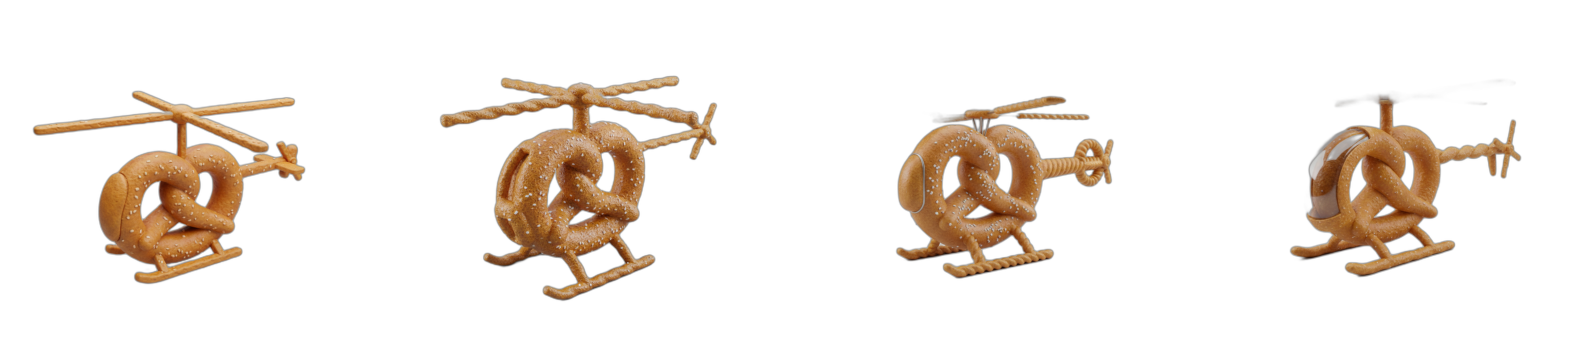

In [ ]:
prompt = "a pretzel-copter, a helicopter where the cockpit is in a pretzel (bavarian brezen) shape and the whole helicopter looks like a pretzel"
prompt_suffix = " Render of high quality 3D model on neutral background. Solid, contiguous mesh, optimized for 3D printing."
prompt = prompt + prompt_suffix

batch_size = 4

# Check text safety first
is_safe, scores = content_moderator.check_text_safety(prompt)
if not is_safe:
    print(f"⚠️ Prompt flagged by content moderation: {scores}")
    print("Please use a different prompt.")
else:
    print("✅ Prompt passed content moderation")
    
    # Use generation pipeline to create images
    print("🎨 Generating images...")
    filtered_images, images = generation_pipeline.generate_images_return_raw(
        prompt, 
        num_images=batch_size,
        base_seed=13,  # Fixed seed for reproducibility
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps
    )
    
    print(f"✅ Generated {len(filtered_images)} images")
    
    # Display images with background removal
    plt.figure(figsize=(20, 15))
    for i in range(len(filtered_images)):
        plt.subplot(1, len(filtered_images), i + 1)
        image = filtered_images[i]
        output = rembg.remove(image)
        plt.imshow(output)
        plt.axis('off')
    plt.show()

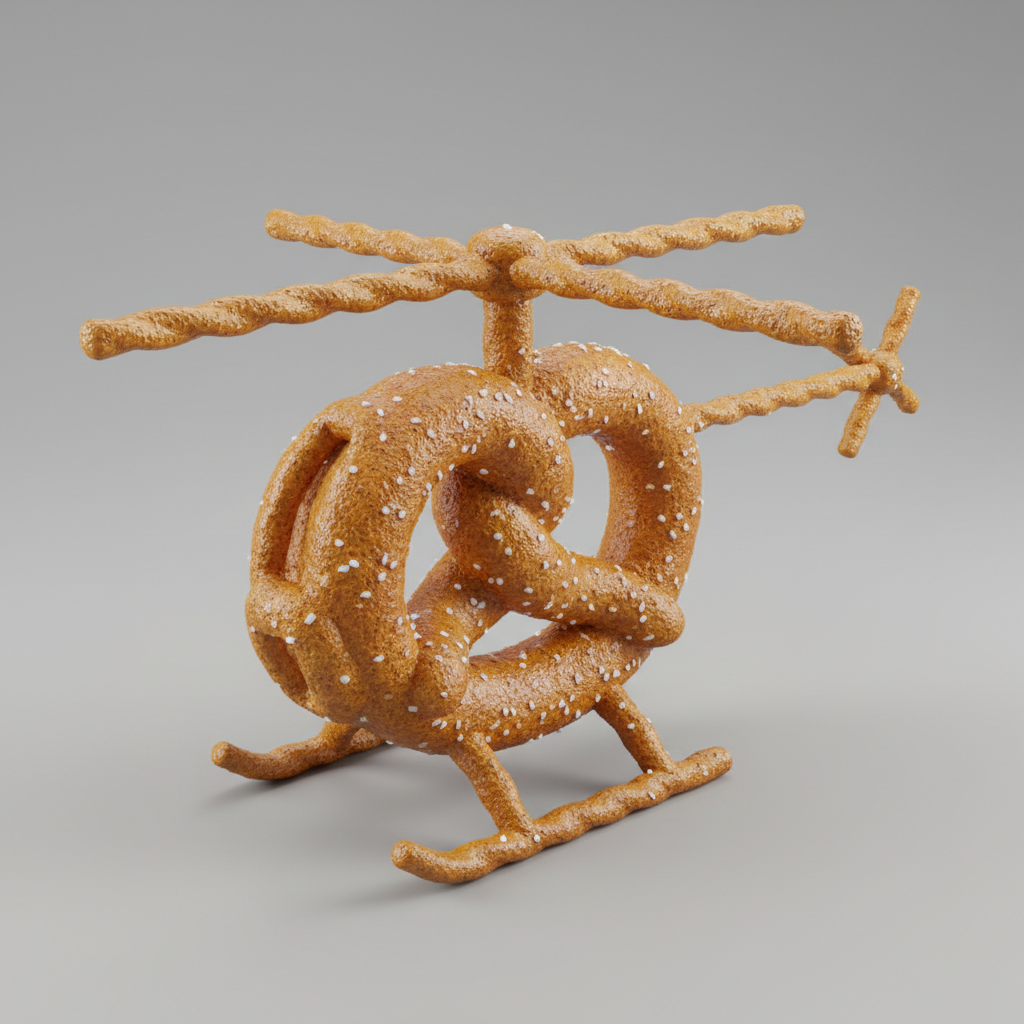

In [4]:
best_image_idx = 1
selected_image = filtered_images[best_image_idx]
selected_image

In [12]:
# Use generation pipeline for 3D model creation with CPU offloading and simple GLB export
video_path, glb_path = generation_pipeline.generate_3d_model(
    selected_image,
    sample_video=True,
    texture_size=512,
    base_seed=3,  # Fixed seed for reproducibility
    use_simple_glb=False  # Use memory-efficient GLB export to avoid 66TB bug
)

🔮 Generating 3D model with seed: 249523


Sampling: 100%|██████████| 24/24 [00:08<00:00,  2.74it/s]
Rendering: 300it [00:00, 343.07it/s]


Before postprocess: 169480 vertices, 338962 faces


Decimating Mesh: 100%|██████████[00:01<00:00]


After decimate: 3389 vertices, 6779 faces


Rasterizing: 100%|██████████| 1000/1000 [00:00<00:00, 1039.18it/s]
WARNING- Some cuts were necessary to cope with non manifold configuration.


Found 3036 invisible faces
Dual graph: 10152 edges
Mincut solved, start checking the cut
Removed 3245 faces by mincut
INFO- Loaded 1764 vertices and 3534 faces.

100% done 
After remove invisible faces: 1778 vertices, 3543 faces
Removing floating mesh components...
Keeping component 0: 3496 faces
Removing component 1: 42 faces (below threshold 106)
Removing component 2: 1 faces (below threshold 106)
Removing component 3: 1 faces (below threshold 106)
Removing component 4: 1 faces (below threshold 106)
Removing component 5: 1 faces (below threshold 106)
Removing component 6: 1 faces (below threshold 106)
Removed 6 floating components


Rendering: 100it [00:00, 174.25it/s]
Texture baking (opt): optimizing: 100%|██████████| 2500/2500 [00:07<00:00, 316.88it/s, loss=0.0267]


✅ 3D model generated: /tmp/tmp42ieoc4z/gaussian_splat.mp4, /tmp/tmp42ieoc4z/3d_model.glb


In [13]:
# if len(video_path) > 0:
Video(video_path, embed=True, width=800)

In [10]:
# get peak gpu memory usage
for i in range(torch.cuda.device_count()):
    peak = torch.cuda.max_memory_allocated(i) / 1024**3
    print(f"🔝 Peak GPU {i} Memory Usage: {peak:.1f}GB")

🔝 Peak GPU 0 Memory Usage: 39.5GB
🔝 Peak GPU 1 Memory Usage: 0.0GB
